# Cumulative Re-Encoding Residual Compression

**Algorithm variant of Section 7 (closed-loop per-segment):**

At each step `i`, instead of encoding a single residual as an isolated file, we
re-encode the **entire accumulated sequence** `[f_0, r_1, r_2, ..., r_i]` into one
HEVC stream. This lets the codec exploit temporal correlation across all residuals
seen so far.

| Step | List content | Action |
|------|-------------|--------|
| init | `[f_0]` | normalize and add first frame |
| i=0 | `[f_0]` | encode → decode last → get f̂_0 → compute r_1 |
| i=1 | `[f_0, r_1]` | encode → decode last → get r̂_1 → f̂_1 = f̂_0 − r̂_1 → compute r_2 |
| i=k | `[f_0, r_1, …, r_k]` | encode → decode last → update f̂_k → compute r_{k+1} |

**Baseline:** direct HEVC encoding of raw frames at cq = 100 and cq = 99 (§4 quality sweep).

In [1]:
# Add project root to path
import sys
from pathlib import Path
import lovely_tensors as lt
lt.monkey_patch()

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
print(f"Added {project_root} to Python path")

Added /Users/lfbarba/GitHub/sdate to Python path


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from tqdm.auto import tqdm
from skimage.metrics import structural_similarity as _skimage_ssim

from sdate.stream_hvec import HevcGray10Streamer, concat_hevc_segments
from sdate.stream_hvec.stream_gray10 import EncoderParams
from sdate.video_compression.hevc_grayscale import decode_hevc_grayscale_10bit
from inct.dataset_slices import ProjectionSliceDataset

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
DATA_PATH = Path('../data/ct_files/file_1_extracted')
NUM_PROJECTIONS = 10
TARGET_SIZE = (2560//2, 2160//2)

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=True,
)

volume = dataset.get_full_volume()  # (H, W, D)

H, W = volume.shape[:2]
N_FRAMES = volume.shape[2]
print(f"\nVolume shape: {volume.shape}")
print(f"Image size:   {H} × {W}")
print(f"Total frames: {N_FRAMES}")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: True
🔬 Loading dark and flat field images...


Loading flats: 100%|██████████| 100/100 [00:02<00:00, 48.42it/s]


   Dark average range: [73.50, 1674.00]
   Flat average range: [31456.00, 48802.50]
ProjectionSliceDataset:
  Volume shape: (1080, 1280, 10)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,382,400
Loading 10 projections...
Volume shape: (1080, 1280, 10)
Total voxels: 13,824,000
Value range: [-0.0672, 1.5127]

Volume shape: torch.Size([1080, 1280, 10])
Image size:   1080 × 1280
Total frames: 10


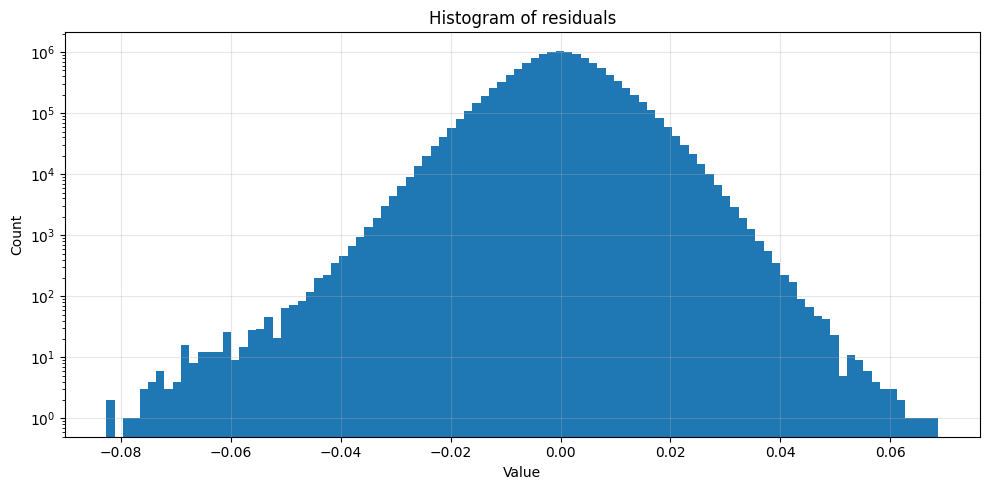

min=-0.082715, max=0.068806, mean=-0.000069, std=0.008275


tensor[9, 1080, 1280] n=12441600 (47Mb) x∈[-0.083, 0.069] μ=-6.921e-05 σ=0.008

In [4]:
# Histogram of all values in the loaded volume
residuals = (volume[:, :, 1:] - volume[:, :, :-1])
residuals = residuals.permute(2, 0, 1)  # (D-1, H, W)

plt.figure(figsize=(10, 5))
# histogram in log metric to better visualize the distribution of values
plt.hist(residuals.ravel(), bins=100, log=True)

plt.title('Histogram of residuals')
plt.xlabel('Value')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"min={residuals.min():.6f}, max={residuals.max():.6f}, mean={residuals.mean():.6f}, std={residuals.std():.6f}")
residuals

## Metric Helpers

In [5]:
def psnr(pred: np.ndarray, tgt: np.ndarray) -> float:
    dr = float(tgt.max() - tgt.min())
    mse = float(np.mean((np.clip(pred, tgt.min(), tgt.max()) - tgt) ** 2))
    return 10 * math.log10(dr ** 2 / (mse + 1e-10))

def ssim(pred: np.ndarray, tgt: np.ndarray) -> float:
    dr = float(tgt.max() - tgt.min())
    return float(_skimage_ssim(tgt, np.clip(pred, tgt.min(), tgt.max()), data_range=dr))

print("Metric helpers ready")

Metric helpers ready


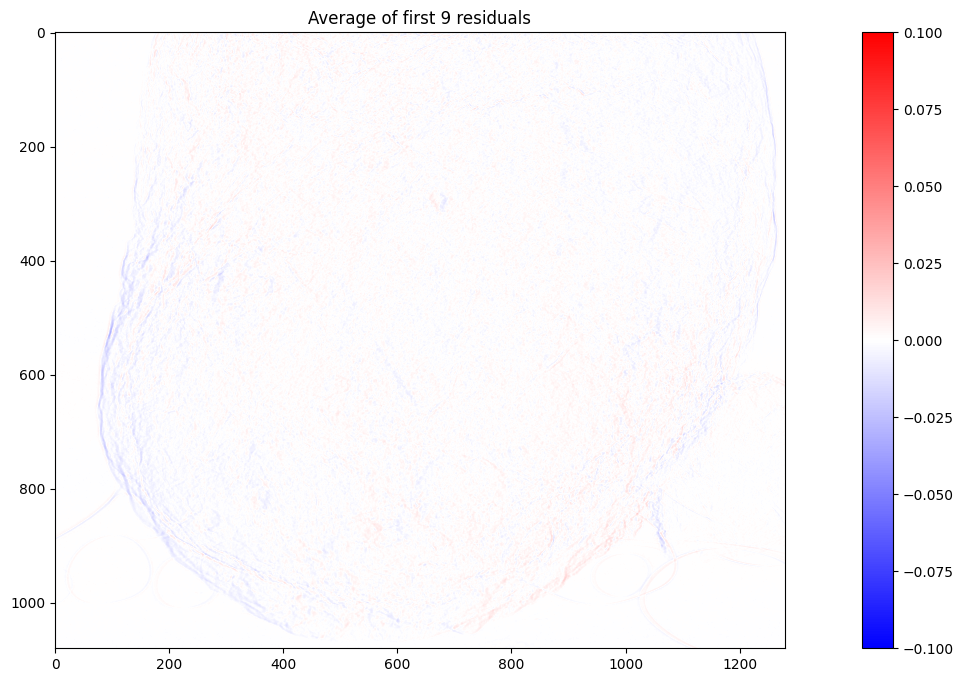

In [6]:
avg = torch.zeros_like(residuals[0])
interval = (0, 9)
for i in range(interval[0], interval[1]):
    avg += (residuals[i] - residuals[i].mean())
avg /= (interval[1] - interval[0])
plt.figure(figsize=(20, 8))
plt.imshow((avg), cmap='bwr', vmin=-0.1, vmax=0.1)
plt.title(f"Average of first {interval[1] - interval[0]} residuals")
plt.colorbar()

tensor[1080, 1280] n=1382400 (5.3Mb) x∈[-1.000, 1.000] μ=0.000 σ=0.343

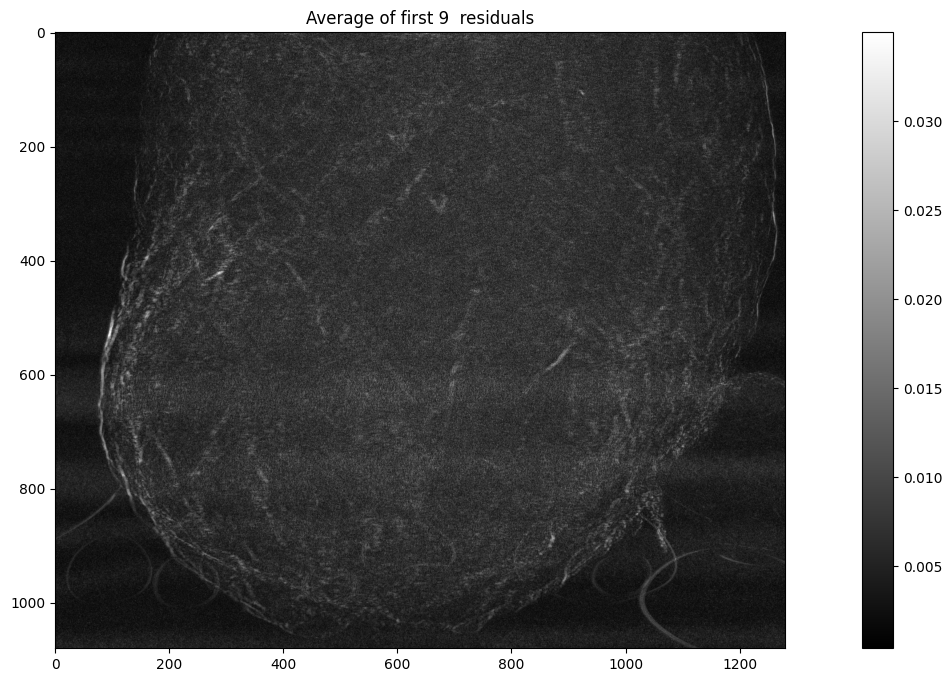

In [7]:
abs_avg = torch.zeros_like(residuals[0])
for i in range(interval[0], interval[1]):
    abs_avg += (residuals[i] - residuals[i].mean()).abs()
abs_avg /= (interval[1] - interval[0])
plt.figure(figsize=(20, 8))
plt.imshow(abs_avg[:])
plt.title(f"Average of first {interval[1] - interval[0]}  residuals")
plt.colorbar()
avg / (abs_avg + 1e-10)

tensor[1080, 1280] n=1382400 (5.3Mb) x∈[-1.000, 1.000] μ=0.000 σ=0.343

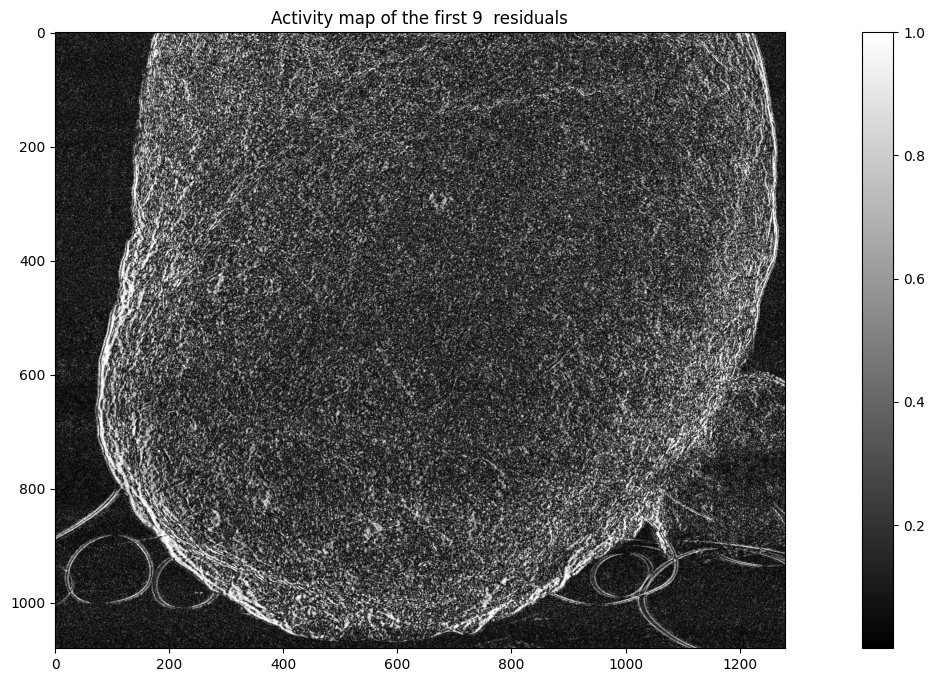

In [8]:
plt.figure(figsize=(20, 8))
activity_map = (avg / (abs_avg + 1e-10)).abs()
plt.imshow(activity_map)
plt.title(f"Activity map of the first {interval[1] - interval[0]}  residuals")
plt.colorbar()
avg / (abs_avg + 1e-10)

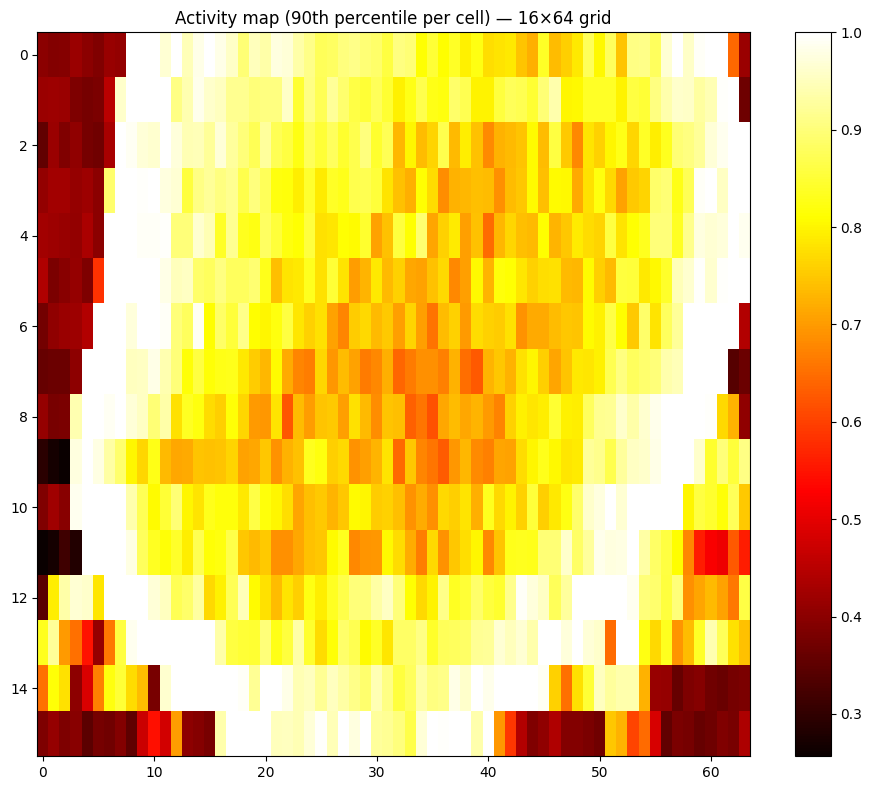

In [9]:

m_h = 16  # number of rows in the grid
m_w = 64  # number of columns in the grid

H_am, W_am = activity_map.shape
cell_h = H_am // m_h
cell_w = W_am // m_w

# Crop to exact multiple, reshape into (m_h, m_w, cell_h*cell_w), then take 90th percentile per cell
cropped = activity_map[:cell_h * m_h, :cell_w * m_w]
grid = (cropped.reshape(m_h, cell_h, m_w, cell_w)
               .permute(0, 2, 1, 3)                   # (m_h, m_w, cell_h, cell_w)
               .reshape(m_h, m_w, -1)                  # (m_h, m_w, cell_h*cell_w)
               .quantile(0.99, dim=-1))                  # (m_h, m_w)

# Match figure aspect ratio to the original activity_map
aspect = W_am / H_am  # original width / height
fig_h = 8
fig_w = fig_h * aspect

plt.figure(figsize=(fig_w, fig_h))
plt.imshow(grid.numpy(), cmap='hot', aspect='auto')
plt.title(f"Activity map (90th percentile per cell) — {m_h}×{m_w} grid")
plt.colorbar()
plt.tight_layout()
plt.show()



## Activity-Adaptive Grid HEVC Encoding

Each frame is split into an **m_h × m_w** grid. Each cell is encoded into a **separate HEVC stream**, with its `cq_hw` quality parameter assigned proportionally to the cell's **activity level** (from the map above):

- **High-activity cells** → higher `cq_hw` (better quality — more information to preserve)  
- **Low-activity cells** → lower `cq_hw` (more compression — region is nearly static)

Activity is linearly mapped from `[act_min, act_max]` → `[CQ_LO, CQ_HI]`.  
After decoding, cells are reassembled into full frames for metric evaluation and compression-ratio analysis.


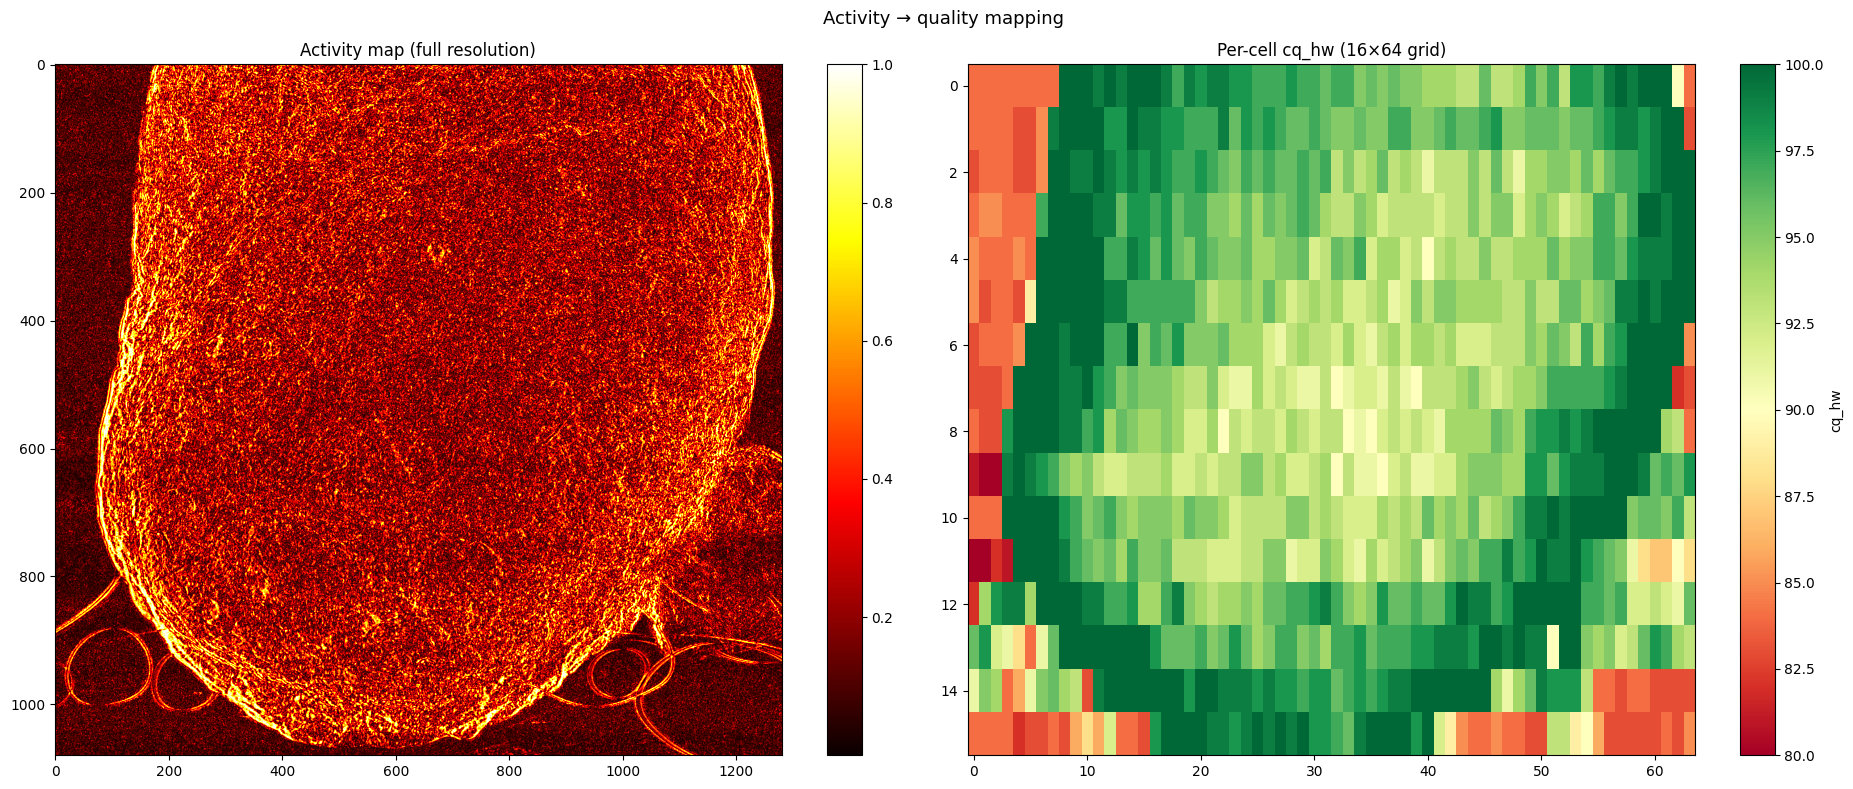

Activity: [0.2566, 1.0000]  |  cq_hw: [80, 100]
Grid: 16×64 = 1024 cells  |  cq_hw ∈ [80, 100]


In [10]:

CQ_LO = 80  # cq_hw for least-active cells
CQ_HI = 100 # cq_hw for most-active cells

# Map averaged activity grid → per-cell cq_hw linearly in [CQ_LO, CQ_HI]
act_lo, act_hi = float(grid.min()), float(grid.max())
cq_grid = CQ_LO + (grid - act_lo) / (act_hi - act_lo + 1e-8) * (CQ_HI - CQ_LO)
cq_grid = cq_grid.round().clamp(CQ_LO, CQ_HI).int()  # (m_h, m_w)

# Visualise: activity map alongside per-cell cq assignment
fig, axes = plt.subplots(1, 2, figsize=(fig_w * 2, fig_h))
im0 = axes[0].imshow(activity_map.numpy(), cmap='hot', aspect='auto')
axes[0].set_title('Activity map (full resolution)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(cq_grid.numpy(), cmap='RdYlGn', vmin=CQ_LO, vmax=CQ_HI,
                     aspect='auto')
axes[1].set_title(f'Per-cell cq_hw ({m_h}×{m_w} grid)')
plt.colorbar(im1, ax=axes[1], label='cq_hw')

plt.suptitle('Activity → quality mapping', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Activity: [{act_lo:.4f}, {act_hi:.4f}]  |  cq_hw: [{cq_grid.min().item()}, {cq_grid.max().item()}]")
print(f"Grid: {m_h}×{m_w} = {m_h * m_w} cells  |  cq_hw ∈ [{CQ_LO}, {CQ_HI}]")


In [11]:

# ── Per-frame normalization ───────────────────────────────────────────────
frame_norms_g: list[tuple[float, float]] = []
frames_normed_g: list[torch.Tensor] = []
for fi in range(N_FRAMES):
    f = volume[:, :, fi]
    fmin, fmax = float(f.min()), float(f.max())
    frame_norms_g.append((fmin, fmax))
    frames_normed_g.append(((f - fmin) / (fmax - fmin + 1e-8)).float())

# ── Cell boundary slices (last row/col extends to cover full H × W) ───────
_rsl = [slice(r * cell_h, (r + 1) * cell_h if r < m_h - 1 else H) for r in range(m_h)]
_csl = [slice(c * cell_w, (c + 1) * cell_w if c < m_w - 1 else W) for c in range(m_w)]

# ── Encode each grid cell into its own HEVC stream ────────────────────────
grid_outdir = Path('grid_adaptive_output')
grid_outdir.mkdir(parents=True, exist_ok=True)

cell_seg_paths: dict[tuple[int, int], Path] = {}

for r in tqdm(range(m_h), desc="Encoding grid rows"):
    for c in range(m_w):
        cq_cell = int(cq_grid[r, c].item())
        streamer_c = HevcGray10Streamer(
            grid_outdir,
            segment_prefix=f"cell_{r:03d}_{c:03d}",
            params=EncoderParams(
                cq_hw=cq_cell,
                preset_sw="medium",
                fps=30,
                force_software=False,
            ),
        )
        with streamer_c.start_segment():
            for fi in range(N_FRAMES):
                streamer_c.append_frame(frames_normed_g[fi][_rsl[r], _csl[c]])
        cell_seg_paths[(r, c)] = streamer_c.segments[0]

total_hevc_grid_bytes = sum(p.stat().st_size for p in cell_seg_paths.values())
print(f"\n✅ {m_h * m_w} cell streams encoded")
print(f"Total HEVC: {total_hevc_grid_bytes / 1e6:.3f} MB")


Encoding grid rows:   0%|          | 0/16 [00:00<?, ?it/s]


✅ 1024 cell streams encoded
Total HEVC: 6.360 MB


In [12]:
# ── Decode and reassemble full frames ─────────────────────────────────────
print("Decoding and reassembling frames ...")
recon_grid = torch.zeros(N_FRAMES, H, W)

for r in tqdm(range(m_h), desc="Decoding grid rows"):
    for c in range(m_w):
        dec = decode_hevc_grayscale_10bit(str(cell_seg_paths[(r, c)]))  # (N, rh, cw)
        rs, cs = _rsl[r], _csl[c]
        tgt_h = rs.stop - rs.start
        tgt_w = cs.stop - cs.start
        for fi in range(N_FRAMES):
            fmin_fi, fmax_fi = frame_norms_g[fi]
            # Crop decoded patch to exact target size (undoes the even-padding from encoding)
            recon_grid[fi, rs, cs] = dec[fi, :tgt_h, :tgt_w].float() * (fmax_fi - fmin_fi + 1e-8) + fmin_fi

# ── Storage accounting ────────────────────────────────────────────────────
raw_bytes_per_frame = H * W * 2          # int16 baseline
raw_total            = N_FRAMES * raw_bytes_per_frame
norm_meta_g          = N_FRAMES * 2 * 4  # per-frame (fmin, fmax) as float32
total_grid_bytes     = total_hevc_grid_bytes + norm_meta_g
cr_grid              = raw_total / total_grid_bytes

# ── Per-frame metrics ─────────────────────────────────────────────────────
grid_metrics = [
    {"psnr": psnr(recon_grid[fi].cpu().numpy(), volume[:, :, fi].cpu().numpy()),
     "ssim": ssim(recon_grid[fi].cpu().numpy(), volume[:, :, fi].cpu().numpy())}
    for fi in range(N_FRAMES)
]
avg_grid_psnr     = float(np.mean([m["psnr"] for m in grid_metrics]))
avg_grid_ssim     = float(np.mean([m["ssim"] for m in grid_metrics]))
avg_grid_psnr_no0 = float(np.mean([m["psnr"] for m in grid_metrics[1:]]))
avg_grid_ssim_no0 = float(np.mean([m["ssim"] for m in grid_metrics[1:]]))

print(f"\n{'─'*60}")
print(f"  Grid cells:      {m_h}×{m_w} = {m_h*m_w}")
print(f"  cq_hw range:     [{CQ_LO}, {CQ_HI}]")
print(f"  Total HEVC:      {total_hevc_grid_bytes/1e6:.3f} MB")
print(f"  Norm metadata:   {norm_meta_g} B")
print(f"  Total:           {total_grid_bytes/1e6:.3f} MB")
print(f"  Raw (int16):     {raw_total/1e6:.3f} MB")
print(f"  CR:              {cr_grid:.2f}×")
print(f"  Avg PSNR (all):       {avg_grid_psnr:.2f} dB")
print(f"  Avg PSNR (excl. f0):  {avg_grid_psnr_no0:.2f} dB")
print(f"  Avg SSIM (all):       {avg_grid_ssim:.4f}")
print(f"  Avg SSIM (excl. f0):  {avg_grid_ssim_no0:.4f}")
print(f"{'─'*60}")

# ── Per-frame PSNR / SSIM ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(N_FRAMES), [m["psnr"] for m in grid_metrics], 'o-',
             color='steelblue', linewidth=1.2, markersize=3)
axes[0].axhline(avg_grid_psnr_no0, color='red', linestyle='--', linewidth=1,
                label=f'Mean (excl. f0) = {avg_grid_psnr_no0:.2f} dB')
axes[0].set_xlabel('Frame index'); axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('Per-frame PSNR — Adaptive Grid'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(N_FRAMES), [m["ssim"] for m in grid_metrics], 'o-',
             color='darkorange', linewidth=1.2, markersize=3)
axes[1].axhline(avg_grid_ssim_no0, color='red', linestyle='--', linewidth=1,
                label=f'Mean (excl. f0) = {avg_grid_ssim_no0:.4f}')
axes[1].set_xlabel('Frame index'); axes[1].set_ylabel('SSIM')
axes[1].set_title('Per-frame SSIM — Adaptive Grid'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Activity-Adaptive Grid HEVC  (cq=[{CQ_LO},{CQ_HI}], CR={cr_grid:.1f}×, '
             f'Avg PSNR={avg_grid_psnr_no0:.1f} dB excl. f0)', fontsize=13)

plt.tight_layout()
plt.show()

Decoding and reassembling frames ...


Decoding grid rows:   0%|          | 0/16 [00:00<?, ?it/s]

/Users/lfbarba/GitHub/sdate/sdate/video_compression/hevc_grayscale.py:194: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:209.)
  vf = torch.from_numpy(v16).to(torch.float32) / 65535.0


RuntimeError: The expanded size of the tensor (67) must match the existing size (66) at non-singleton dimension 0.  Target sizes: [67, 20].  Tensor sizes: [66, 20]

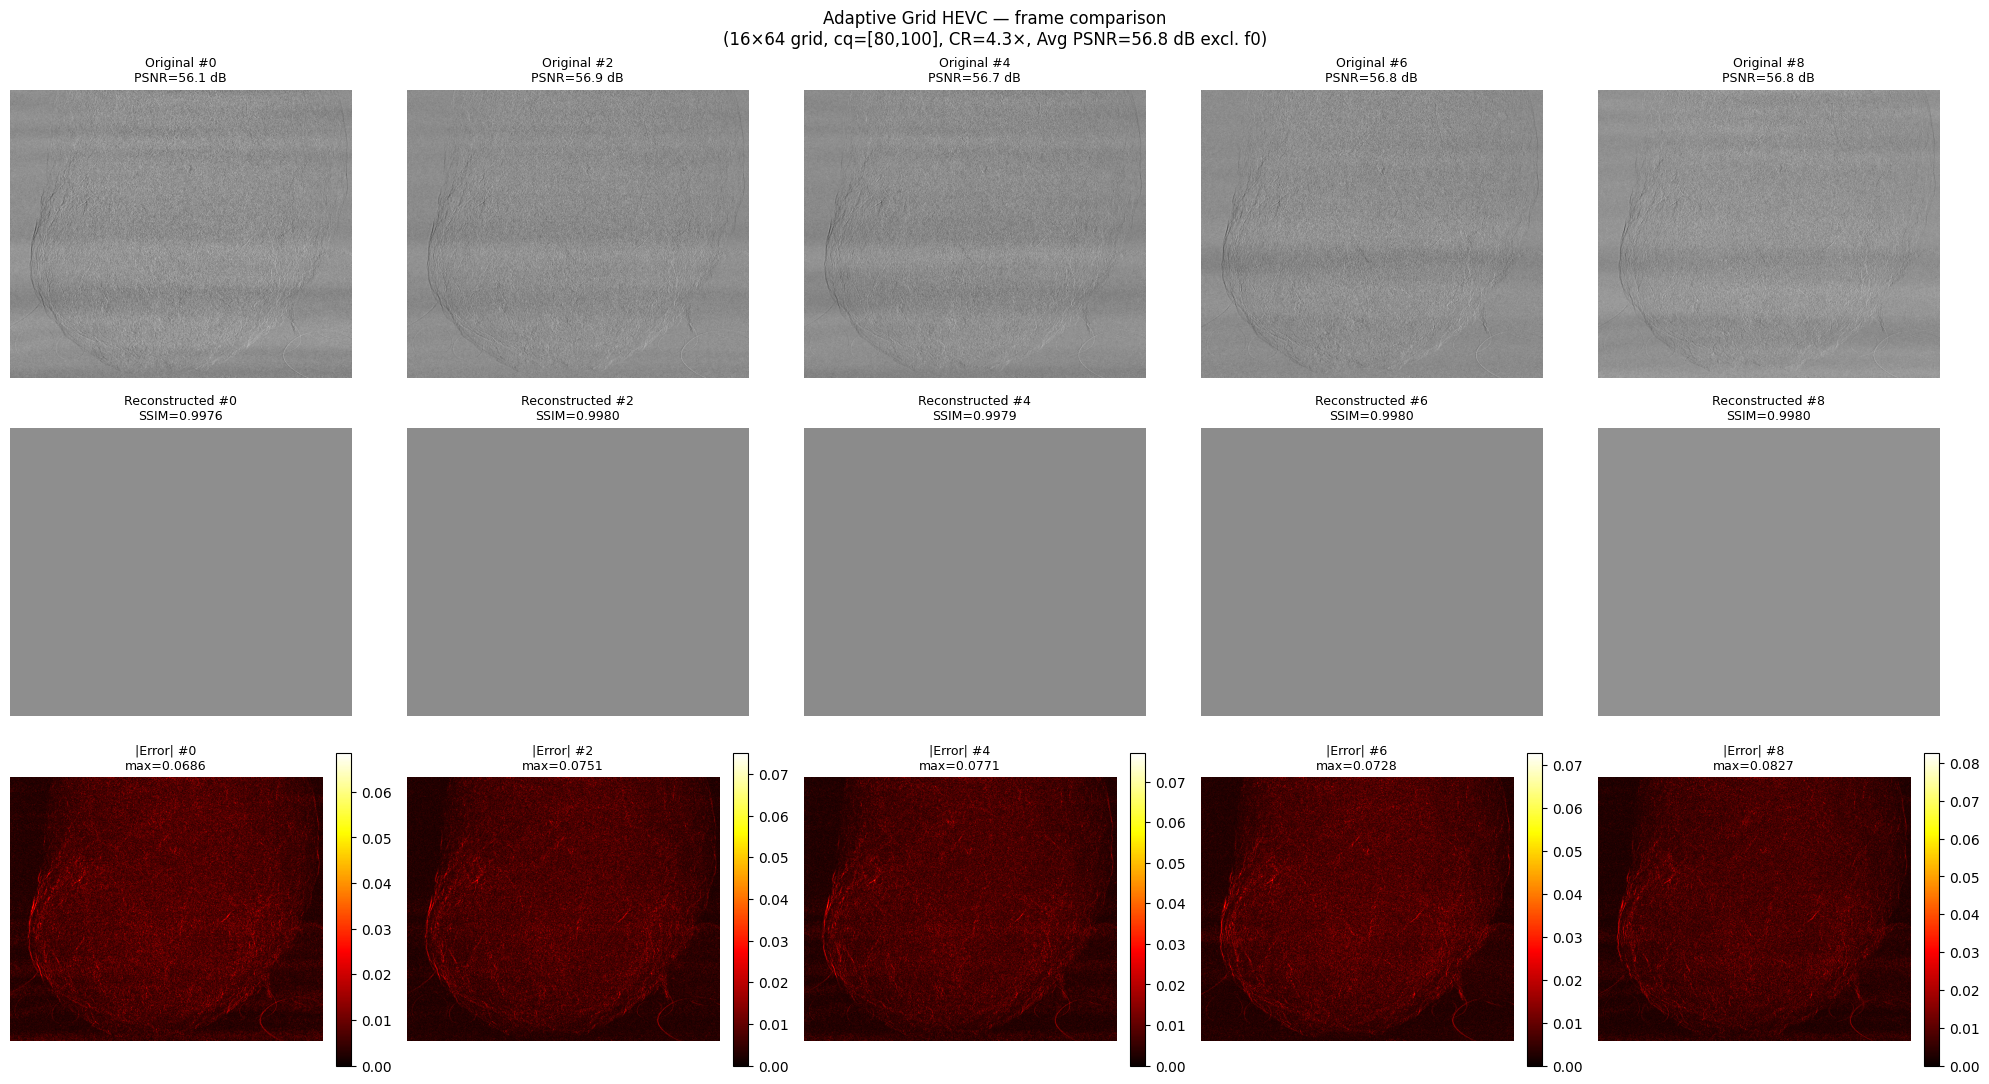

In [ ]:

# ── Sample frames to display ─────────────────────────────────────────────
show_idxs = sorted(set([0, N_FRAMES // 4, N_FRAMES // 2, 3 * N_FRAMES // 4, N_FRAMES - 1]))
n_show = len(show_idxs)

fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 11))

for col, fi in enumerate(show_idxs):
    orig_f = volume[:, :, fi].cpu().numpy()
    rec_f  = recon_grid[fi].cpu().numpy()
    diff_f = np.abs(orig_f - rec_f)
    vmin, vmax = orig_f.min(), orig_f.max()

    axes[0, col].imshow(orig_f, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, col].set_title(f'Original #{fi}\nPSNR={grid_metrics[fi]["psnr"]:.1f} dB', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(rec_f, cmap='gray', vmin=vmin, vmax=vmax)
    axes[1, col].set_title(f'Reconstructed #{fi}\nSSIM={grid_metrics[fi]["ssim"]:.4f}', fontsize=9)
    axes[1, col].axis('off')

    im = axes[2, col].imshow(diff_f, cmap='hot')
    axes[2, col].set_title(f'|Error| #{fi}\nmax={diff_f.max():.4f}', fontsize=9)
    axes[2, col].axis('off')
    plt.colorbar(im, ax=axes[2, col], fraction=0.046, pad=0.04)

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Reconstructed', fontsize=11)
axes[2, 0].set_ylabel('Abs Error', fontsize=11)

plt.suptitle(
    f'Adaptive Grid HEVC — frame comparison\n'
    f'({m_h}×{m_w} grid, cq=[{CQ_LO},{CQ_HI}], CR={cr_grid:.1f}×, '
    f'Avg PSNR={avg_grid_psnr_no0:.1f} dB excl. f0)',
    fontsize=12
)
plt.tight_layout()
plt.show()


In [ ]:

movie_outdir = Path('grid_adaptive_output')
movie_outdir.mkdir(parents=True, exist_ok=True)

params_preview = EncoderParams(cq_hw=100, preset_sw="medium", fps=10, force_software=False)

# ── Reconstructed frames movie ────────────────────────────────────────────
recon_streamer = HevcGray10Streamer(movie_outdir, segment_prefix="recon_preview", params=params_preview)
with recon_streamer.start_segment():
    for fi in range(N_FRAMES):
        frame = recon_grid[fi]
        fmin_f, fmax_f = float(frame.min()), float(frame.max())
        recon_streamer.append_frame(((frame - fmin_f) / (fmax_f - fmin_f + 1e-8)).float())

recon_path = recon_streamer.segments[0]
print(f"Reconstructed movie: {recon_path}  ({recon_path.stat().st_size / 1e3:.1f} kB)")

# ── Absolute diff movie ───────────────────────────────────────────────────
diff_streamer = HevcGray10Streamer(movie_outdir, segment_prefix="diff_preview", params=params_preview)
with diff_streamer.start_segment():
    for fi in range(N_FRAMES):
        orig_f  = volume[:, :, fi].float()
        diff_f  = (recon_grid[fi] - orig_f).abs()
        dmin, dmax = float(diff_f.min()), float(diff_f.max())
        diff_streamer.append_frame(((diff_f - dmin) / (dmax - dmin + 1e-8)).float())

diff_path = diff_streamer.segments[0]
print(f"Diff movie:          {diff_path}  ({diff_path.stat().st_size / 1e3:.1f} kB)")


In [ ]:
BASELINE_QUALITY_LEVELS = [
    {"label": "VHQ (cq=100)", "cq_hw": 100},
    {"label": "HQ  (cq=99)",  "cq_hw": 99},
]

baseline_outdir = Path('baseline_hevc_output')
baseline_outdir.mkdir(parents=True, exist_ok=True)

# Pre-compute per-frame normalisation for the raw frames
frame_norms_bl: list[tuple[float, float]] = []
frames_normed_bl: list[torch.Tensor] = []
for fi in range(N_FRAMES):
    f = volume[:, :, fi]
    fmin, fmax = float(f.min()), float(f.max())
    frame_norms_bl.append((fmin, fmax))
    frames_normed_bl.append(((f - fmin) / (fmax - fmin + 1e-8)).float())

baseline_results: dict = {}

for ql in BASELINE_QUALITY_LEVELS:
    label  = ql["label"]
    cq     = ql["cq_hw"]
    print(f"\n{'═'*60}")
    print(f"  Baseline: {label}")
    print(f"{'═'*60}")

    params_bl = EncoderParams(
        cq_hw=cq,
        preset_sw="medium",
        fps=10,
        force_software=False,
    )

    streamer_bl = HevcGray10Streamer(
        baseline_outdir,
        segment_prefix=f"baseline_cq{cq}",
        params=params_bl,
    )
    with streamer_bl.start_segment():
        for fn in frames_normed_bl:
            streamer_bl.append_frame(fn)

    seg_path_bl = streamer_bl.segments[0]
    hevc_bytes_bl = seg_path_bl.stat().st_size
    norm_meta_bl  = N_FRAMES * 2 * 4
    total_bl      = hevc_bytes_bl + norm_meta_bl
    cr_bl         = raw_total / total_bl

    print(f"  HEVC file:     {hevc_bytes_bl/1e6:.3f} MB")
    print(f"  Total:         {total_bl/1e6:.3f} MB")
    print(f"  CR:            {cr_bl:.2f}×")

    # Decode and reconstruct
    decoded_bl = decode_hevc_grayscale_10bit(str(seg_path_bl))  # (N_FRAMES, H, W)
    recon_bl   = torch.zeros(N_FRAMES, H, W)
    for fi in range(N_FRAMES):
        fmin_fi, fmax_fi = frame_norms_bl[fi]
        recon_bl[fi] = decoded_bl[fi].float() * (fmax_fi - fmin_fi + 1e-8) + fmin_fi

    # Per-frame metrics
    metrics_bl = []
    for fi in range(N_FRAMES):
        rec_np = recon_bl[fi].cpu().numpy()
        tgt_np = volume[:, :, fi].cpu().numpy()
        metrics_bl.append({"psnr": psnr(rec_np, tgt_np), "ssim": ssim(rec_np, tgt_np)})

    avg_psnr_bl     = float(np.mean([m["psnr"] for m in metrics_bl]))
    avg_ssim_bl     = float(np.mean([m["ssim"] for m in metrics_bl]))
    avg_psnr_bl_no0 = float(np.mean([m["psnr"] for m in metrics_bl[1:]]))
    avg_ssim_bl_no0 = float(np.mean([m["ssim"] for m in metrics_bl[1:]]))

    print(f"  Avg PSNR (all):       {avg_psnr_bl:.2f} dB")
    print(f"  Avg PSNR (excl. f0):  {avg_psnr_bl_no0:.2f} dB")
    print(f"  Avg SSIM (all):       {avg_ssim_bl:.4f}")
    print(f"  Avg SSIM (excl. f0):  {avg_ssim_bl_no0:.4f}")

    baseline_results[label] = {
        "cq":           cq,
        "recon":        recon_bl.clone(),
        "metrics":      metrics_bl,
        "total_bytes":  total_bl,
        "hevc_bytes":   hevc_bytes_bl,
        "cr":           cr_bl,
        "avg_psnr":     avg_psnr_bl,
        "avg_ssim":     avg_ssim_bl,
        "avg_psnr_no0": avg_psnr_bl_no0,
        "avg_ssim_bl_no0": avg_ssim_bl_no0,
    }

print("\n✅  Baseline encoding complete")


## Residual-Based Adaptive Grid HEVC Encoding

Instead of encoding raw frames, encode the **inter-frame residuals** `r_i = f_i − f_{i-1}` (one fewer than the number of frames).  
The first frame `f_0` is stored losslessly as a NumPy array.

Reconstruction accumulates decoded residuals on top of `f_0`:

$$\hat{f}_0 = f_0, \qquad \hat{f}_i = \hat{f}_{i-1} + \hat{r}_i, \quad i = 1, \ldots, N-1$$

The same activity-adaptive `cq_grid` is reused for the per-cell quality assignment.


In [ ]:

N_RESIDUALS = N_FRAMES - 1  # residuals has one fewer entry than frames

resid_outdir = Path('residual_grid_output')
resid_outdir.mkdir(parents=True, exist_ok=True)

# ── Store f_0 losslessly ─────────────────────────────────────────────────
f0 = volume[:, :, 0].float()
f0_path = resid_outdir / "f0.npy"
np.save(str(f0_path), f0.cpu().numpy())
print(f"f_0 saved: {f0_path}  ({f0_path.stat().st_size / 1e3:.1f} kB)")

# ── Per-residual normalization ────────────────────────────────────────────
# residuals shape: (N_FRAMES-1, H, W)
resid_norms: list[tuple[float, float]] = []
residuals_normed: list[torch.Tensor] = []
for ri in range(N_RESIDUALS):
    r = residuals[ri]
    rmin, rmax = float(r.min()), float(r.max())
    resid_norms.append((rmin, rmax))
    residuals_normed.append(((r - rmin) / (rmax - rmin + 1e-8)).float())

# ── Encode each grid cell ─────────────────────────────────────────────────
resid_cell_paths: dict[tuple[int, int], Path] = {}

for r in tqdm(range(m_h), desc="Encoding residual grid rows"):
    for c in range(m_w):
        cq_cell = int(cq_grid[r, c].item())
        streamer_r = HevcGray10Streamer(
            resid_outdir,
            segment_prefix=f"resid_{r:03d}_{c:03d}",
            params=EncoderParams(cq_hw=cq_cell, preset_sw="medium", fps=10, force_software=False),
        )
        with streamer_r.start_segment():
            for ri in range(N_RESIDUALS):
                patch = residuals_normed[ri][_rsl[r], _csl[c]]
                ph, pw = patch.shape
                pad_h, pad_w = ph % 2, pw % 2
                if pad_h or pad_w:
                    patch = torch.nn.functional.pad(
                        patch.unsqueeze(0).unsqueeze(0),
                        (0, pad_w, 0, pad_h), mode='replicate'
                    ).squeeze(0).squeeze(0)
                streamer_r.append_frame(patch)
        resid_cell_paths[(r, c)] = streamer_r.segments[0]

total_hevc_resid_bytes = sum(p.stat().st_size for p in resid_cell_paths.values())
print(f"\n✅ {m_h * m_w} residual cell streams encoded")
print(f"Total HEVC: {total_hevc_resid_bytes / 1e6:.3f} MB")


f_0 saved: residual_grid_output/f0.npy  (5529.7 kB)


Encoding residual grid rows:   0%|          | 0/16 [00:00<?, ?it/s]


✅ 1024 residual cell streams encoded
Total HEVC: 11.492 MB


Decoding residuals and reconstructing frames ...


Decoding residual grid rows:   0%|          | 0/16 [00:00<?, ?it/s]


────────────────────────────────────────────────────────────
  Grid cells:      16×64 = 1024
  cq_hw range:     [80, 100]
  HEVC residuals:  11.492 MB
  f_0 (lossless):  5529.7 kB
  Norm metadata:   64 B
  Total:           17.022 MB
  Raw (int16):     27.648 MB
  CR:              1.62×
  Avg PSNR (all):       23.04 dB
  Avg PSNR (excl. f0):  15.70 dB
  Avg SSIM (all):       0.1145
  Avg SSIM (excl. f0):  0.0038
────────────────────────────────────────────────────────────


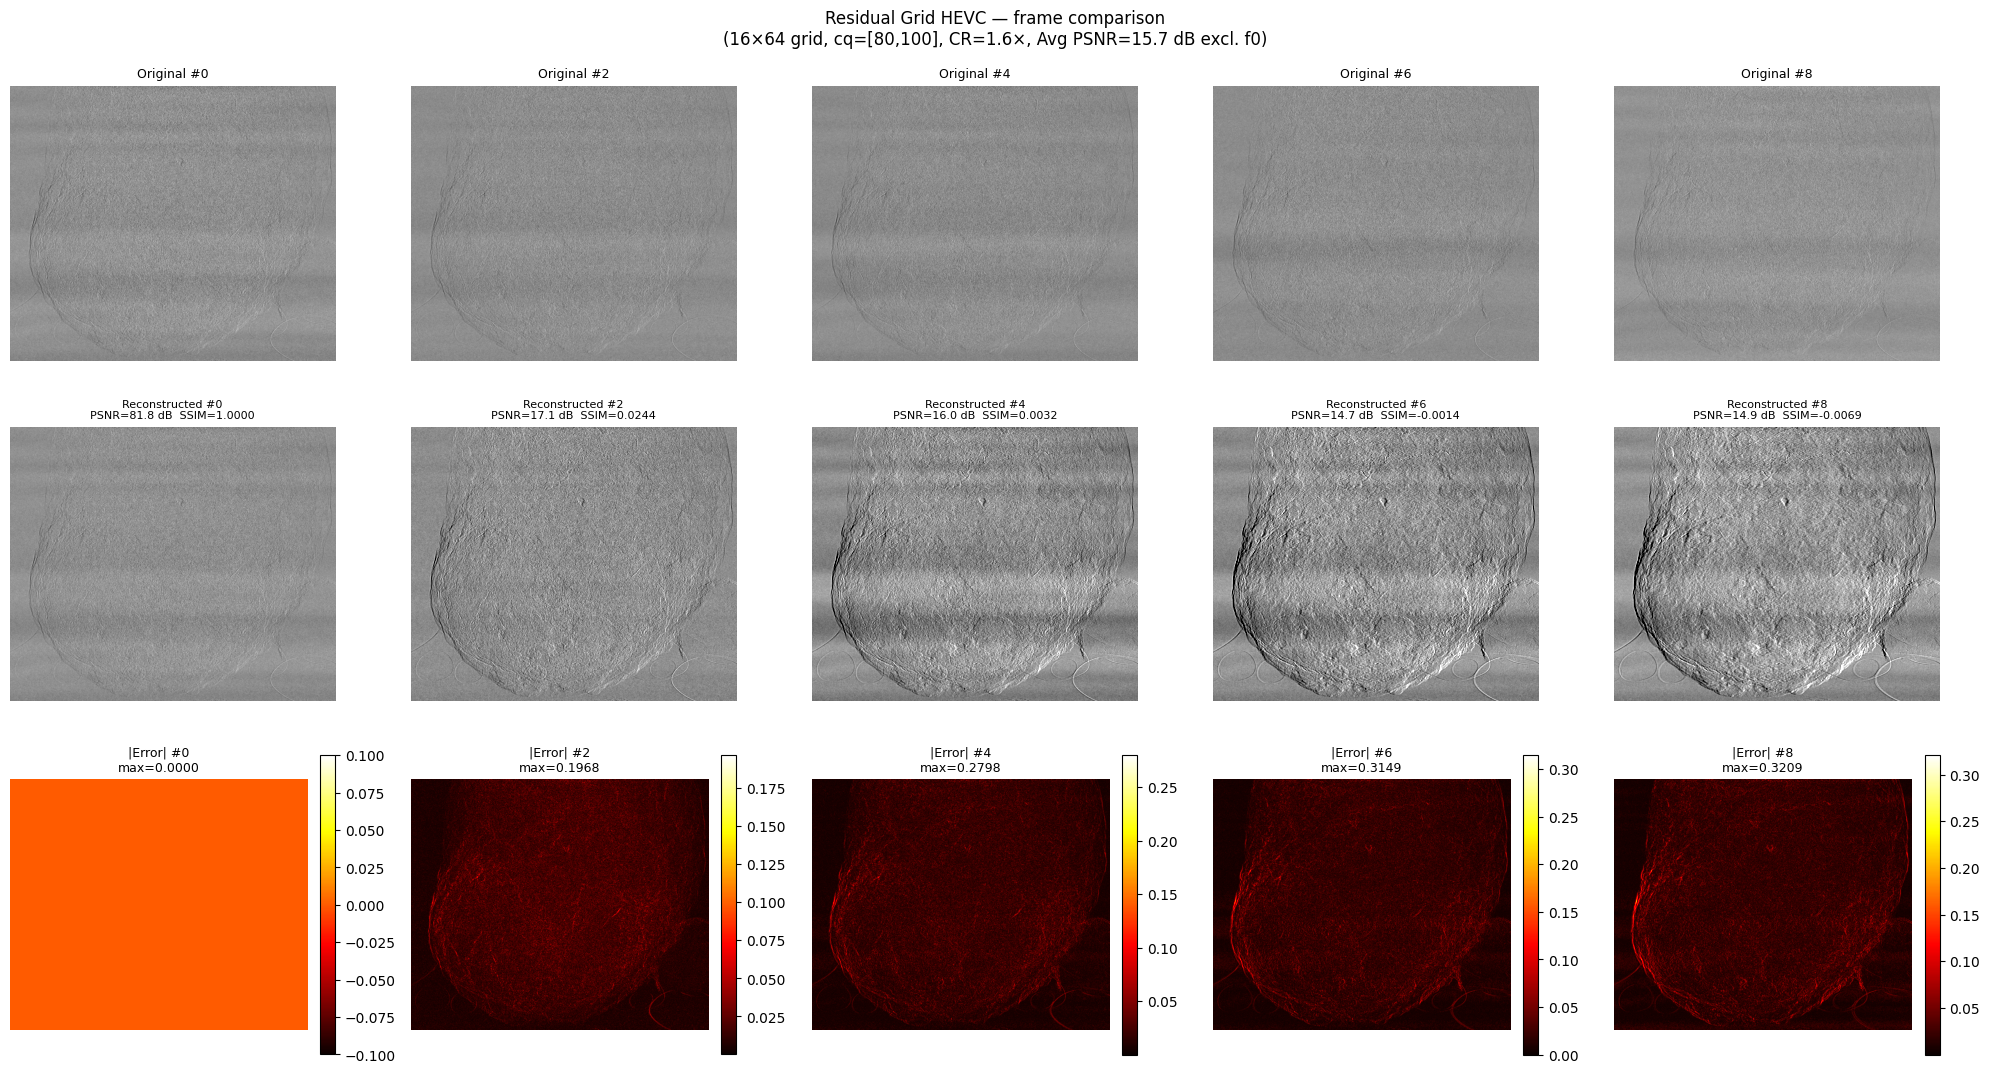

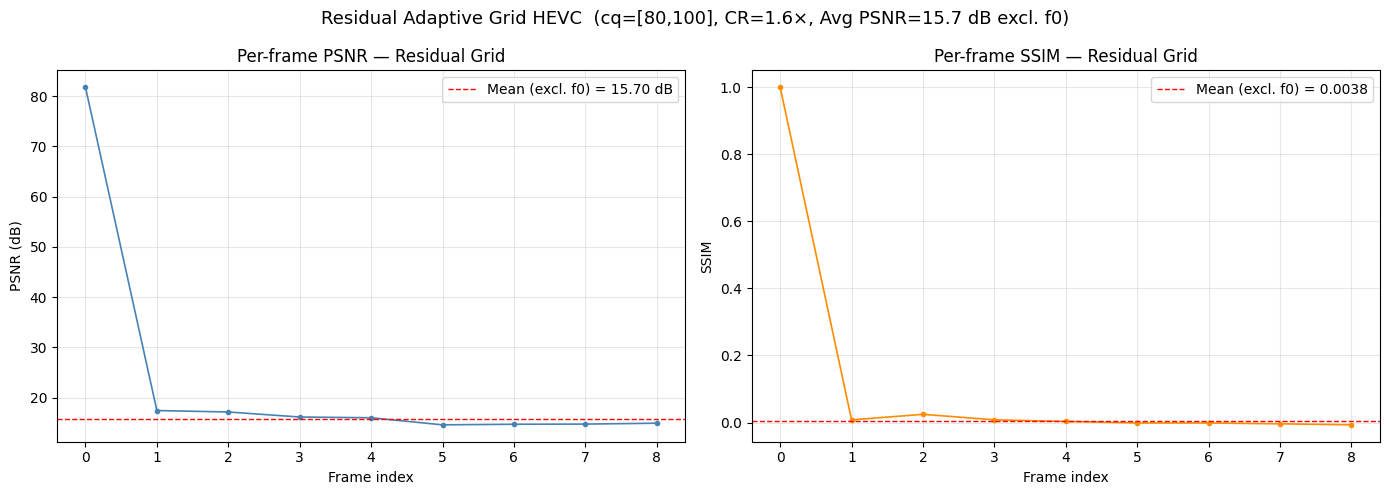

In [ ]:

# ── Decode and reassemble residuals → reconstruct frames ─────────────────
print("Decoding residuals and reconstructing frames ...")
decoded_residuals = torch.zeros(N_RESIDUALS, H, W)

for r in tqdm(range(m_h), desc="Decoding residual grid rows"):
    for c in range(m_w):
        dec = decode_hevc_grayscale_10bit(str(resid_cell_paths[(r, c)]))  # (N_RESIDUALS, rh, cw)
        rs, cs = _rsl[r], _csl[c]
        tgt_h = rs.stop - rs.start
        tgt_w = cs.stop - cs.start
        for ri in range(N_RESIDUALS):
            rmin, rmax = resid_norms[ri]
            decoded_residuals[ri, rs, cs] = (
                dec[ri, :tgt_h, :tgt_w].float() * (rmax - rmin + 1e-8) + rmin
            )

# ── Accumulate residuals onto f_0 ────────────────────────────────────────
f0_loaded = torch.from_numpy(np.load(str(f0_path))).float()
recon_resid = torch.zeros(N_FRAMES, H, W)
recon_resid[0] = f0_loaded
for fi in range(1, N_FRAMES):
    recon_resid[fi] = recon_resid[fi - 1] + decoded_residuals[fi - 1]

# ── Storage accounting ────────────────────────────────────────────────────
resid_norm_meta   = N_RESIDUALS * 2 * 4      # (rmin, rmax) per residual as float32
f0_bytes          = f0_path.stat().st_size
total_resid_bytes = total_hevc_resid_bytes + resid_norm_meta + f0_bytes
cr_resid          = raw_total / total_resid_bytes

# ── Per-frame metrics ─────────────────────────────────────────────────────
resid_metrics = [
    {"psnr": psnr(recon_resid[fi].cpu().numpy(), residuals[fi].cpu().numpy()),
     "ssim": ssim(recon_resid[fi].cpu().numpy(), residuals[fi].cpu().numpy())}
    for fi in range(N_FRAMES)
]
avg_resid_psnr     = float(np.mean([m["psnr"] for m in resid_metrics]))
avg_resid_ssim     = float(np.mean([m["ssim"] for m in resid_metrics]))
avg_resid_psnr_no0 = float(np.mean([m["psnr"] for m in resid_metrics[1:]]))
avg_resid_ssim_no0 = float(np.mean([m["ssim"] for m in resid_metrics[1:]]))

print(f"\n{'─'*60}")
print(f"  Grid cells:      {m_h}×{m_w} = {m_h*m_w}")
print(f"  cq_hw range:     [{CQ_LO}, {CQ_HI}]")
print(f"  HEVC residuals:  {total_hevc_resid_bytes/1e6:.3f} MB")
print(f"  f_0 (lossless):  {f0_bytes/1e3:.1f} kB")
print(f"  Norm metadata:   {resid_norm_meta} B")
print(f"  Total:           {total_resid_bytes/1e6:.3f} MB")
print(f"  Raw (int16):     {raw_total/1e6:.3f} MB")
print(f"  CR:              {cr_resid:.2f}×")
print(f"  Avg PSNR (all):       {avg_resid_psnr:.2f} dB")
print(f"  Avg PSNR (excl. f0):  {avg_resid_psnr_no0:.2f} dB")
print(f"  Avg SSIM (all):       {avg_resid_ssim:.4f}")
print(f"  Avg SSIM (excl. f0):  {avg_resid_ssim_no0:.4f}")
print(f"{'─'*60}")

# ── Frame comparison: original vs reconstructed vs abs error ──────────────
show_idxs_r = sorted(set([0, N_FRAMES // 4, N_FRAMES // 2, 3 * N_FRAMES // 4, N_FRAMES - 1]))
fig, axes = plt.subplots(3, len(show_idxs_r), figsize=(4 * len(show_idxs_r), 11))

for col, fi in enumerate(show_idxs_r):
    orig_f = volume[:, :, fi].cpu().numpy()
    rec_f  = recon_resid[fi].cpu().numpy()
    diff_f = np.abs(orig_f - rec_f)
    vmin_f, vmax_f = orig_f.min(), orig_f.max()

    axes[0, col].imshow(orig_f, cmap='gray', vmin=vmin_f, vmax=vmax_f)
    axes[0, col].set_title(f'Original #{fi}', fontsize=9); axes[0, col].axis('off')

    axes[1, col].imshow(rec_f, cmap='gray', vmin=vmin_f, vmax=vmax_f)
    axes[1, col].set_title(
        f'Reconstructed #{fi}\nPSNR={resid_metrics[fi]["psnr"]:.1f} dB  '
        f'SSIM={resid_metrics[fi]["ssim"]:.4f}', fontsize=8)
    axes[1, col].axis('off')

    im = axes[2, col].imshow(diff_f, cmap='hot')
    axes[2, col].set_title(f'|Error| #{fi}\nmax={diff_f.max():.4f}', fontsize=9)
    axes[2, col].axis('off')
    plt.colorbar(im, ax=axes[2, col], fraction=0.046, pad=0.04)

axes[0, 0].set_ylabel('Original', fontsize=11)
axes[1, 0].set_ylabel('Reconstructed', fontsize=11)
axes[2, 0].set_ylabel('Abs Error', fontsize=11)
plt.suptitle(
    f'Residual Grid HEVC — frame comparison\n'
    f'({m_h}×{m_w} grid, cq=[{CQ_LO},{CQ_HI}], CR={cr_resid:.1f}×, '
    f'Avg PSNR={avg_resid_psnr_no0:.1f} dB excl. f0)',
    fontsize=12
)
plt.tight_layout()
plt.show()

# ── Per-frame PSNR / SSIM ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(N_FRAMES), [m["psnr"] for m in resid_metrics], 'o-',
             color='steelblue', linewidth=1.2, markersize=3)
axes[0].axhline(avg_resid_psnr_no0, color='red', linestyle='--', linewidth=1,
                label=f'Mean (excl. f0) = {avg_resid_psnr_no0:.2f} dB')
axes[0].set_xlabel('Frame index'); axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('Per-frame PSNR — Residual Grid'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(N_FRAMES), [m["ssim"] for m in resid_metrics], 'o-',
             color='darkorange', linewidth=1.2, markersize=3)
axes[1].axhline(avg_resid_ssim_no0, color='red', linestyle='--', linewidth=1,
                label=f'Mean (excl. f0) = {avg_resid_ssim_no0:.4f}')
axes[1].set_xlabel('Frame index'); axes[1].set_ylabel('SSIM')
axes[1].set_title('Per-frame SSIM — Residual Grid'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'Residual Adaptive Grid HEVC  (cq=[{CQ_LO},{CQ_HI}], CR={cr_resid:.1f}×, '
    f'Avg PSNR={avg_resid_psnr_no0:.1f} dB excl. f0)',
    fontsize=13
)
plt.tight_layout()
plt.show()


In [ ]:
recon_resid[fi], 

(tensor[1080, 1280] n=1382400 (5.3Mb) x∈[-0.313, 0.197] μ=-0.001 σ=0.025,
 tensor[1080, 1280] n=1382400 (5.3Mb) x∈[-0.083, 0.063] μ=0.000 σ=0.008)

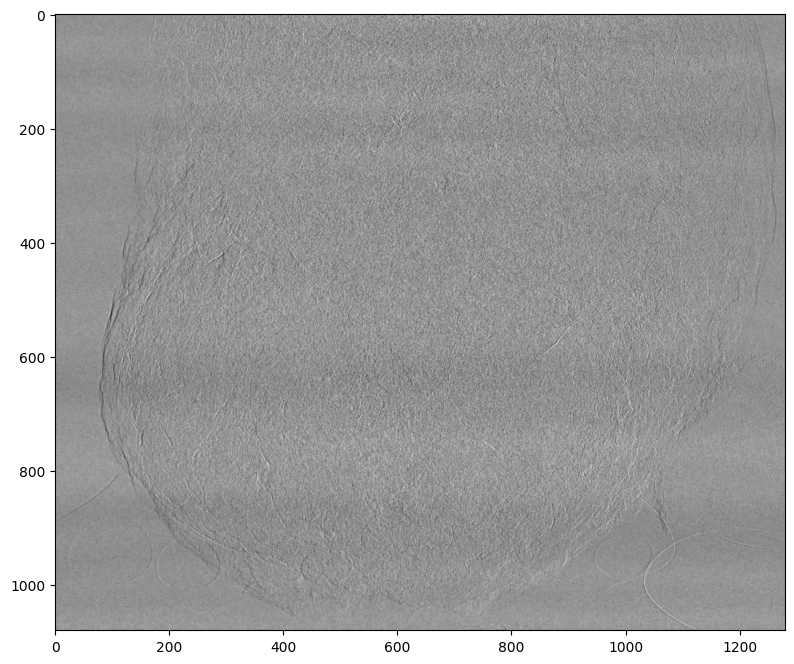

In [ ]:
plt.figure(figsize=(10, 8))
plt.imshow(residuals[fi].cpu(), cmap='gray')